# Combined Filter

Loads processed outputs from `mems_filter.ipynb` and `spec_filter.ipynb` and merges them into one DataFrame per sub-dataset.

**Run both source notebooks first** (execute their export cells) before running this notebook.

| Sub-dataset | Source file | MEMS | SPEC | ENV |
|-------------|-------------|------|------|-----|
| Sweat 1a | `20260405-experiment/sweat.csv` | VOC, NH3, HCHO | H2S, EtOH | temp, RH |
| Sweat 1b | `20260405-experiment/sweat.csv` | VOC, NH3, HCHO | H2S, EtOH | temp, RH |
| Blood 0  | `20260406-experiment/1.5_blood.csv` | VOC, NH3, HCHO | H2S, EtOH | temp, RH |
| Blood 1  | `20260406-experiment/1.5_blood_2.csv` | VOC, NH3, HCHO | H2S, EtOH | temp, RH |

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

PROCESSED = "processed"

MEMS = ["voc", "nh3", "hcho"]
SPEC = ["h2s_ppm", "etoh_ppm"]
ENV  = ["temp_C", "rh_pct"]
ALL_CHANNELS = MEMS + SPEC + ENV

# ── Load pickles ──────────────────────────────────────────────────────────────
mems = {
    "sweat_1a": pd.read_pickle(f"{PROCESSED}/mems_sweat_1a.pkl"),
    "sweat_1b": pd.read_pickle(f"{PROCESSED}/mems_sweat_1b.pkl"),
    "blood_0":  pd.read_pickle(f"{PROCESSED}/mems_blood_0.pkl"),
    "blood_1":  pd.read_pickle(f"{PROCESSED}/mems_blood_1.pkl"),
}
spec = {
    "sweat_1a": pd.read_pickle(f"{PROCESSED}/spec_sweat_1a.pkl"),
    "sweat_1b": pd.read_pickle(f"{PROCESSED}/spec_sweat_1b.pkl"),
    "blood_0":  pd.read_pickle(f"{PROCESSED}/spec_blood_0.pkl"),
    "blood_1":  pd.read_pickle(f"{PROCESSED}/spec_blood_1.pkl"),
}

print("MEMS pickles loaded:")
for k, df in mems.items():
    print(f"  {k:<10}  {len(df):5} rows  elapsed {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f} s  cols: {list(df.columns)}")

print("\nSPEC pickles loaded:")
for k, df in spec.items():
    print(f"  {k:<10}  {len(df):5} rows  elapsed {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f} s  cols: {list(df.columns)}")


MEMS pickles loaded:
  sweat_1a     3909 rows  elapsed 0–4000 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  sweat_1b     2390 rows  elapsed 0–2446 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_0      3666 rows  elapsed 0–3753 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_1      1908 rows  elapsed 1751–3703 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']

SPEC pickles loaded:
  sweat_1a     3909 rows  elapsed 0–4000 s  cols: ['elapsed_s', 'h2s_ppm', 'etoh_ppm']
  sweat_1b     2390 rows  elapsed 0–2446 s  cols: ['elapsed_s', 'h2s_ppm', 'etoh_ppm']
  blood_0      3666 rows  elapsed 0–3753 s  cols: ['elapsed_s', 'h2s_ppm', 'etoh_ppm']
  blood_1      3618 rows  elapsed 0–3703 s  cols: ['elapsed_s', 'h2s_ppm', 'etoh_ppm']


## Merge

MEMS and SPEC data come from the same CSV recorded at 1 Hz, so `elapsed_s` values align exactly. Merge on `elapsed_s` with `how='inner'` to keep only rows present in both.

In [87]:
datasets = {}

for key in mems:
    m = mems[key]
    s = spec[key]

    merged = pd.merge(m, s[["elapsed_s"] + SPEC], on="elapsed_s", how="inner")
    merged = merged[["elapsed_s"] + ALL_CHANNELS].reset_index(drop=True)
    datasets[key] = merged

print("Combined datasets:")
print(f"  {'Name':<10}  {'Rows':>6}  {'elapsed range':>20}  Channels")
print(f"  {'-'*65}")
for key, df in datasets.items():
    t0, t1 = df['elapsed_s'].iloc[0], df['elapsed_s'].iloc[-1]
    print(f"  {key:<10}  {len(df):>6}  {t0:>8.0f} – {t1:>6.0f} s    {list(df.columns)}")


Combined datasets:
  Name          Rows         elapsed range  Channels
  -----------------------------------------------------------------
  sweat_1a      3909         0 –   4000 s    ['elapsed_s', 'voc', 'nh3', 'hcho', 'h2s_ppm', 'etoh_ppm', 'temp_C', 'rh_pct']
  sweat_1b      2390         0 –   2446 s    ['elapsed_s', 'voc', 'nh3', 'hcho', 'h2s_ppm', 'etoh_ppm', 'temp_C', 'rh_pct']
  blood_0       3666         0 –   3753 s    ['elapsed_s', 'voc', 'nh3', 'hcho', 'h2s_ppm', 'etoh_ppm', 'temp_C', 'rh_pct']
  blood_1       1908      1751 –   3703 s    ['elapsed_s', 'voc', 'nh3', 'hcho', 'h2s_ppm', 'etoh_ppm', 'temp_C', 'rh_pct']


## Channel Verification

In [88]:
for key, df in datasets.items():
    print(f"\n{key}")
    print(f"  {'Channel':<12} {'min':>10} {'max':>10} {'nulls':>8}")
    print(f"  {'-'*44}")
    for col in ALL_CHANNELS:
        null_count = df[col].isna().sum()
        print(f"  {col:<12} {df[col].min():>10.4f} {df[col].max():>10.4f} {null_count:>8}")



sweat_1a
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.7439        0
  nh3              0.0000     0.0890        0
  hcho             0.0000     0.0690        0
  h2s_ppm          0.0000     0.3742        0
  etoh_ppm         0.0000    29.7009        0
  temp_C          19.3000    19.9000        0
  rh_pct          35.4000    60.2000        0

sweat_1b
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.1400        0
  nh3              0.0000     0.0297        0
  hcho             0.0000     0.0146        0
  h2s_ppm          0.0000     0.5434        0
  etoh_ppm         0.0000     0.0000        0
  temp_C          19.6000    19.8000        0
  rh_pct          37.5000    70.5000        0

blood_0
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.4901        0
  

## Data Labelling

Each row is assigned one of three labels based on the time the sample was physically present in the sensor chamber:

| Label | Value | Meaning |
|-------|-------|---------|
| `baseline` | 0 | No sample present |
| `sweat`    | 1 | Sweat sample in chamber |
| `blood`    | 2 | Blood sample in chamber |

**Sample windows** (elapsed seconds within each sub-dataset):

| Sub-dataset | Window | Label |
|-------------|--------|-------|
| Sweat 1a | 2800 – 3760 s | sweat |
| Sweat 1b | TBD | sweat |
| Blood 0  | TBD | blood |
| Blood 1  | TBD | blood |


In [89]:
LABEL_BASELINE = 0
LABEL_SWEAT    = 1
LABEL_BLOOD    = 2

# Sample windows: list of (t_start, t_end, label) per sub-dataset.
# Rows outside all windows default to LABEL_BASELINE.
SAMPLE_WINDOWS = {
    "sweat_1a": [(2870, 3850, LABEL_SWEAT)],
    "sweat_1b": [(570, 2330, LABEL_SWEAT)],   
    "blood_0":  [(1900, 3730, LABEL_BLOOD)],   
    "blood_1":  [(2440, 3800, LABEL_BLOOD)],   
}

for key, df in datasets.items():
    datasets[key] = df.copy()
    datasets[key]["label"] = LABEL_BASELINE
    for t_start, t_end, lbl in SAMPLE_WINDOWS[key]:
        mask = (df["elapsed_s"] >= t_start) & (df["elapsed_s"] <= t_end)
        datasets[key].loc[mask, "label"] = lbl

# Summary
print(f"{'Dataset':<12}  {'baseline':>10}  {'sweat':>8}  {'blood':>8}  {'total':>8}")
print("-" * 52)
for key, df in datasets.items():
    b  = (df["label"] == LABEL_BASELINE).sum()
    sw = (df["label"] == LABEL_SWEAT).sum()
    bl = (df["label"] == LABEL_BLOOD).sum()
    print(f"{key:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(df):>8}")


Dataset         baseline     sweat     blood     total
----------------------------------------------------
sweat_1a            2952       957         0      3909
sweat_1b             671      1719         0      2390
blood_0             1879         0      1787      3666
blood_1              674         0      1234      1908


### Label Visualization

Shaded regions show the labelled time windows — **grey** = baseline, **green** = sweat, **red** = blood.

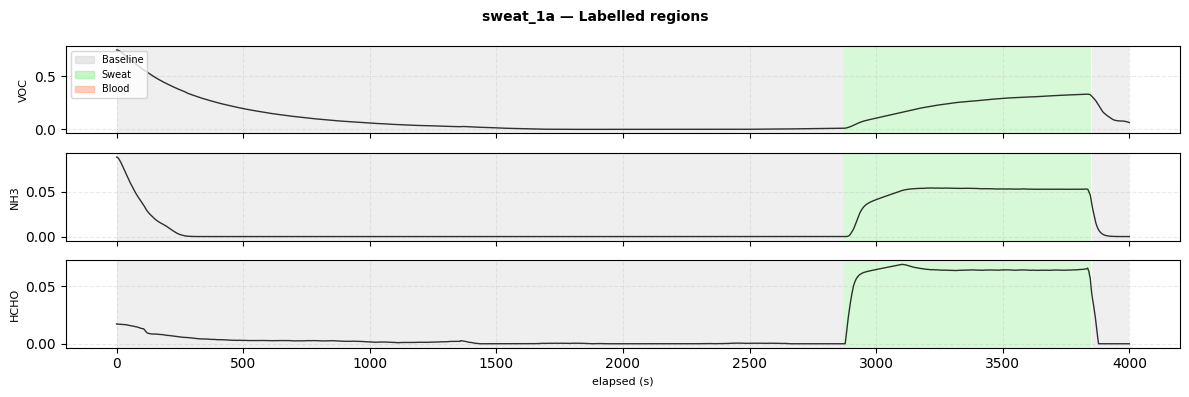

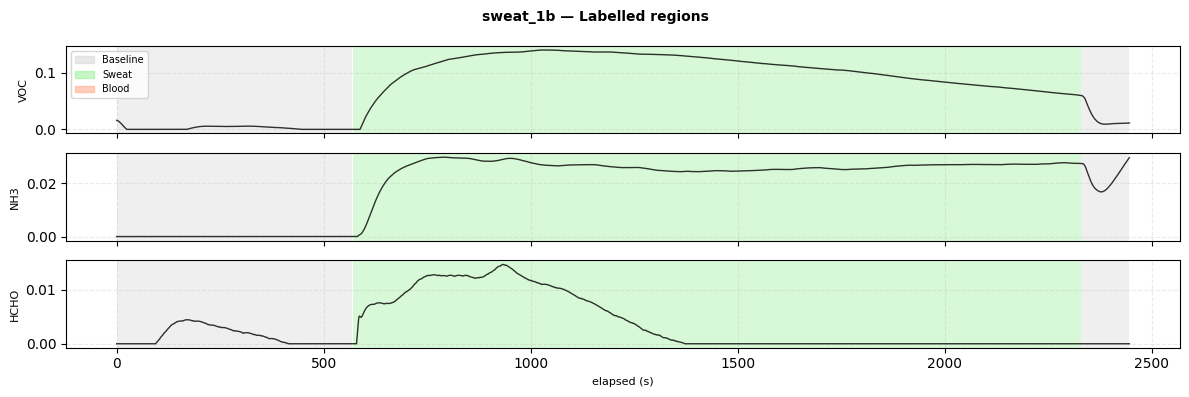

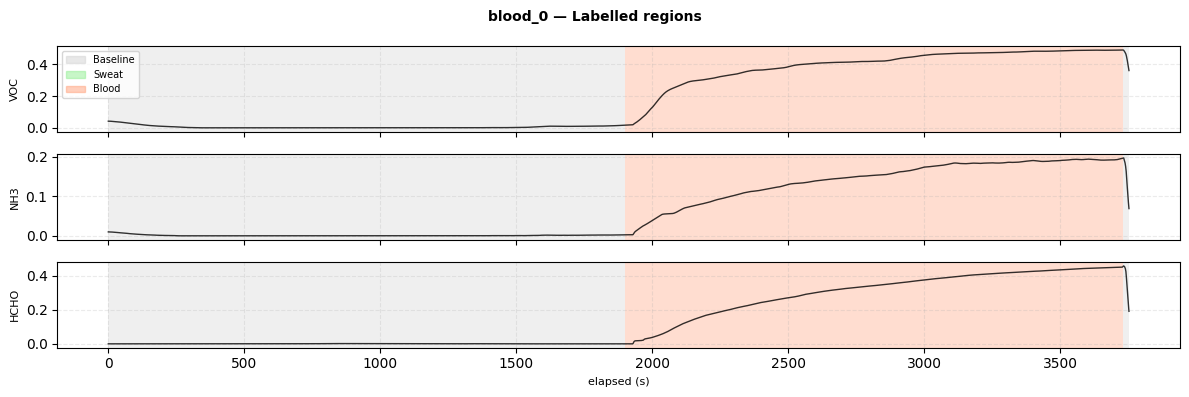

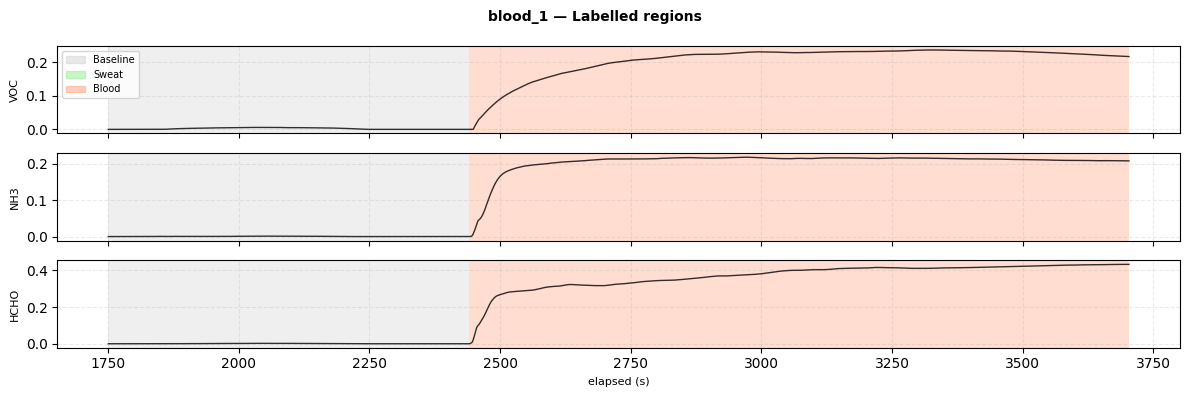

In [90]:
import matplotlib.patches as mpatches

REGION_COLORS = {
    LABEL_BASELINE: ("lightgrey",  "Baseline"),
    LABEL_SWEAT:    ("lightgreen", "Sweat"),
    LABEL_BLOOD:    ("lightsalmon","Blood"),
}
PLOT_COLS = ["voc", "nh3", "hcho"]

for key, df in datasets.items():
    fig, axes = plt.subplots(len(PLOT_COLS), 1, figsize=(12, 4), sharex=True)
    fig.suptitle(f"{key} — Labelled regions", fontsize=10, fontweight="bold")

    # Draw label regions as background spans
    label_changes = df[["elapsed_s", "label"]].copy()
    label_changes["block"] = (label_changes["label"] != label_changes["label"].shift()).cumsum()
    for _, grp in label_changes.groupby("block"):
        t0   = grp["elapsed_s"].iloc[0]
        t1   = grp["elapsed_s"].iloc[-1]
        lbl  = grp["label"].iloc[0]
        color, _ = REGION_COLORS[lbl]
        for ax in axes:
            ax.axvspan(t0, t1, color=color, alpha=0.35, linewidth=0)

    # Plot signals
    for ax, col in zip(axes, PLOT_COLS):
        ax.plot(df["elapsed_s"], df[col], linewidth=1.0, color="black", alpha=0.8)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.grid(True, alpha=0.25, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)

    # Legend
    patches = [mpatches.Patch(color=c, label=l, alpha=0.5)
               for _, (c, l) in REGION_COLORS.items()]
    axes[0].legend(handles=patches, fontsize=7, loc="upper left")

    plt.tight_layout()
    plt.show()

## Model Creation

### Helper Columns

Computed per row before windowing. Each column is causal (uses only past data) so compatible with real-time inference.

**Multi-scale rolling mean** — signal level over 15s, 30s, 60s lookbacks:
```
{col}_roll_mean_15,  {col}_roll_mean_30,  {col}_roll_mean_60
```

**Multi-scale rolling std** — signal volatility over 15s, 30s, 60s:
```
{col}_roll_std_15,  {col}_roll_std_30,  {col}_roll_std_60
```

**Rate of change (ROC)** — instantaneous change between consecutive samples:
```
{col}_roc
```

**Multi-scale rolling ROC** — smoothed rate of change over 15s, 30s, 60s:
```
{col}_roll_roc_15,  {col}_roll_roc_30,  {col}_roll_roc_60
```

**Acceleration** — rate of change of the ROC (2nd derivative). Captures whether the sensor response is speeding up or plateauing:
```
{col}_acc


In [91]:
CHANNELS = ["voc", "nh3", "hcho", "h2s_ppm", "etoh_ppm", "rh_pct"]
ROLL_WINDOWS = [15, 30, 60]   # seconds (= samples at 1 Hz)

for key in datasets:
    df = datasets[key].copy()

    for col in CHANNELS:
        # Rate of change (1st derivative)
        df[f"{col}_roc"] = df[col].diff()

        # Acceleration (2nd derivative)
        df[f"{col}_acc"] = df[f"{col}_roc"].diff()

        # Multi-scale rolling mean, std, ROC
        for w in ROLL_WINDOWS:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
            df[f"{col}_roll_roc_{w}"]  = df[f"{col}_roc"].abs().rolling(window=w, min_periods=1).mean()

    datasets[key] = df

# Summary
sample = datasets["sweat_1a"]
helper_cols = [c for c in sample.columns if any(
    c.endswith(s) for s in ["_roc", "_acc", "_mean_15", "_mean_30", "_mean_60",
                             "_std_15", "_std_30", "_std_60",
                             "_roc_15", "_roc_30", "_roc_60"]
)]
print(f"Helper columns added per dataset: {len(helper_cols)}")
print(f"Total columns: {len(sample.columns)}")
print(f"\nHelper columns:")
for c in helper_cols:
    print(f"  {c}")


Helper columns added per dataset: 66
Total columns: 75

Helper columns:
  voc_roc
  voc_acc
  voc_roll_mean_15
  voc_roll_std_15
  voc_roll_roc_15
  voc_roll_mean_30
  voc_roll_std_30
  voc_roll_roc_30
  voc_roll_mean_60
  voc_roll_std_60
  voc_roll_roc_60
  nh3_roc
  nh3_acc
  nh3_roll_mean_15
  nh3_roll_std_15
  nh3_roll_roc_15
  nh3_roll_mean_30
  nh3_roll_std_30
  nh3_roll_roc_30
  nh3_roll_mean_60
  nh3_roll_std_60
  nh3_roll_roc_60
  hcho_roc
  hcho_acc
  hcho_roll_mean_15
  hcho_roll_std_15
  hcho_roll_roc_15
  hcho_roll_mean_30
  hcho_roll_std_30
  hcho_roll_roc_30
  hcho_roll_mean_60
  hcho_roll_std_60
  hcho_roll_roc_60
  h2s_ppm_roc
  h2s_ppm_acc
  h2s_ppm_roll_mean_15
  h2s_ppm_roll_std_15
  h2s_ppm_roll_roc_15
  h2s_ppm_roll_mean_30
  h2s_ppm_roll_std_30
  h2s_ppm_roll_roc_30
  h2s_ppm_roll_mean_60
  h2s_ppm_roll_std_60
  h2s_ppm_roll_roc_60
  etoh_ppm_roc
  etoh_ppm_acc
  etoh_ppm_roll_mean_15
  etoh_ppm_roll_std_15
  etoh_ppm_roll_roc_15
  etoh_ppm_roll_mean_30
  etoh_pp

### Windowed Feature Extraction

Slide a **60s non-overlapping window** over labeled rows (sweat, blood, and undersampled baseline). Per window extract:

- **Mean, std, slope, max** for each channel and its helper columns (VOC, NH3, HCHO, H2S, EtOH)
- **Mean temp_C and rh_pct** as environmental context

Each window becomes one feature vector with a single class label (baseline=0, sweat=1, blood=2).

In [92]:
import numpy as np

WINDOW_SIZE = 60   # seconds = samples at 1 Hz

# Columns to extract features from (channels + all helper columns)
EXCLUDE_COLS = {"elapsed_s", "label", "temp_C", "rh_pct"}
FEATURE_COLS = [c for c in datasets["sweat_1a"].columns if c not in EXCLUDE_COLS]

def extract_window_features(window_df, feature_cols):
    features = {}
    t = np.arange(len(window_df))

    for col in feature_cols:
        vals = window_df[col].values
        features[f"{col}_mean"]  = np.nanmean(vals)
        features[f"{col}_std"]   = np.nanstd(vals)
        features[f"{col}_max"]   = np.nanmax(vals)
        slope, _ = np.polyfit(t, vals, 1) if len(vals) > 1 else (0.0, 0.0)
        features[f"{col}_slope"] = slope


    return features

# ── Slide window per (session, label) — never cross boundaries ────────────────
all_windows = []

for session, df in datasets.items():
    for label in [LABEL_BASELINE, LABEL_SWEAT, LABEL_BLOOD]:
        label_df = df[df["label"] == label].reset_index(drop=True)
        n_windows = len(label_df) // WINDOW_SIZE

        for i in range(n_windows):
            window = label_df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
            feats  = extract_window_features(window, FEATURE_COLS)
            feats["label"]   = label
            feats["session"] = session
            all_windows.append(feats)

windows_df = pd.DataFrame(all_windows)

# ── Undersample baseline to match largest sample class ───────────────────────
baseline_w = windows_df[windows_df["label"] == LABEL_BASELINE]
sweat_w    = windows_df[windows_df["label"] == LABEL_SWEAT]
blood_w    = windows_df[windows_df["label"] == LABEL_BLOOD]

n_target         = max(len(sweat_w), len(blood_w))
baseline_sampled = baseline_w.sample(n=min(n_target, len(baseline_w)), random_state=42)

windows_balanced = pd.concat([sweat_w, blood_w, baseline_sampled]).reset_index(drop=True)

print(f"Windows before balancing:")
print(f"  Baseline : {len(baseline_w)}")
print(f"  Sweat    : {len(sweat_w)}")
print(f"  Blood    : {len(blood_w)}")
print(f"\nAfter undersampling baseline → {len(baseline_sampled)} windows:")
print(f"  Total    : {len(windows_balanced)}")
print(f"  Features : {len(windows_balanced.columns) - 2}")  # exclude label + session

print(f"\nWindows per session:")
print(f"  {'Session':<12}  {'Baseline':>10}  {'Sweat':>8}  {'Blood':>8}  {'Total':>8}")
print(f"  {'-'*46}")
for session in windows_df['session'].unique():
    s = windows_df[windows_df['session'] == session]
    b  = (s['label'] == LABEL_BASELINE).sum()
    sw = (s['label'] == LABEL_SWEAT).sum()
    bl = (s['label'] == LABEL_BLOOD).sum()
    print(f"  {session:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(s):>8}")
print(f"  {'-'*46}")
totals = windows_df.groupby('label').size()
print(f"  {'TOTAL':<12}  {totals.get(LABEL_BASELINE,0):>10}  {totals.get(LABEL_SWEAT,0):>8}  {totals.get(LABEL_BLOOD,0):>8}  {len(windows_df):>8}")


Windows before balancing:
  Baseline : 102
  Sweat    : 43
  Blood    : 49

After undersampling baseline → 49 windows:
  Total    : 141
  Features : 284

Windows per session:
  Session         Baseline     Sweat     Blood     Total
  ----------------------------------------------
  sweat_1a              49        15         0        64
  sweat_1b              11        28         0        39
  blood_0               31         0        29        60
  blood_1               11         0        20        31
  ----------------------------------------------
  TOTAL                102        43        49       194


### Training and Evaluation — Random Forest with LOSO (Run 1)

**Setup:**
- 141 total windows (60s non-overlapping) across 4 sessions
- 3-class classification: baseline=0, sweat=1, blood=2
- Baseline undersampled globally to match largest sample class
- Features: mean, std, slope, max for all 5 channels + all helper columns (ROC, acceleration, rolling mean/std/ROC at 15s/30s/60s) + rh_pct helpers
- Model: Random Forest, 200 trees, class_weight="balanced"
- Evaluation: GroupKFold (n_splits=4), split by session

**Observations:**
- Training accuracy is perfect every fold — model overfits to training data
- Fold 3 (blood_0 held out) collapses to random chance (0.333) — blood_0 and blood_1 are too different for one to predict the other
- Fold 4 (blood_1 held out) is perfect — blood_1 is well represented by training
- High std (0.253) makes the mean unreliable
- Too many features relative to window count — helper columns likely adding noise

**Next steps:** Feature selection — restrict to NH3 and HCHO channels which visually show the strongest discrimination between classes.

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

X      = windows_balanced.drop(columns=["label", "session"])
y      = windows_balanced["label"]
groups = windows_balanced["session"]

gkf   = GroupKFold(n_splits=4)
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

results = cross_validate(
    model, X, y,
    cv=gkf.split(X, y, groups),
    scoring=["accuracy"],
    return_train_score=True,
)

print("LOSO Cross-Validation Results")
print("=" * 40)
print(f"  {'Fold':<8}  {'Train Acc':>10}  {'Val Acc':>10}")
print(f"  {'-'*40}")
for i in range(4):
    print(f"  {i+1:<8}  "
          f"{results['train_accuracy'][i]:>10.3f}  "
          f"{results['test_accuracy'][i]:>10.3f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<8}  "
      f"{results['train_accuracy'].mean():>10.3f}  "
      f"{results['test_accuracy'].mean():>10.3f}")
print(f"  {'Std':<8}  "
      f"{results['train_accuracy'].std():>10.3f}  "
      f"{results['test_accuracy'].std():>10.3f}")

# ── Train final model on all data ─────────────────────────────────────────────
final_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
final_model.fit(X, y)
print(f"\nFinal model trained on all {len(X)} windows.")


LOSO Cross-Validation Results
  Fold       Train Acc     Val Acc
  ----------------------------------------
  1              1.000       0.791
  2              1.000       0.884
  3              1.000       0.333
  4              1.000       1.000
  ----------------------------------------
  Mean           1.000       0.752
  Std            0.000       0.253

Final model trained on all 141 windows.


### Training and Evaluation — Random Forest (Run 2)

**Changes from Run 1:**

1. **Reduce trees: 200 → 100**
2. **Feature reduction** — remove roll_mean, roll_std, acc; keep raw aggregates + ROC columns
3. **Simple 80/20 split** — train on 80% of all windows, validate on the remaining 20% (stratified by label so each class is proportionally represented in both sets)

This uses everything we have. Future sessions will serve as true out-of-sample validation.


In [94]:
# ── Feature reduction: drop roll_mean, roll_std, acc ──────────────────────────
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

REMOVE_PATTERNS = ["_roll_mean_", "_roll_std_", "_acc"]

all_feature_cols = [c for c in windows_balanced.columns if c not in ("label", "session")]
feature_cols_r2 = [c for c in all_feature_cols
                   if not any(p in c for p in REMOVE_PATTERNS)]

print(f"Run 1 features: {len(all_feature_cols)}")
print(f"Run 2 features: {len(feature_cols_r2)}\n")

X2     = windows_balanced[feature_cols_r2]
y2     = windows_balanced["label"]
groups = windows_balanced["session"]

# ── 80/20 split — stratified by label ────────────────────────────────────────
X_train, X_test, y_train, y_test, grp_train, grp_test = train_test_split(
    X2, y2, groups,
    test_size=0.2,
    random_state=42,
    stratify=y2,
)

print(f"Train: {len(X_train)} windows")
for sess, count in grp_train.value_counts().sort_index().items():
    print(f"  {sess}: {count} windows")

print(f"\nTest:  {len(X_test)} windows")
for sess, count in grp_test.value_counts().sort_index().items():
    print(f"  {sess}: {count} windows")

# ── Train ─────────────────────────────────────────────────────────────────────
model_r2 = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model_r2.fit(X_train, y_train)

# ── Validate ──────────────────────────────────────────────────────────────────
y_pred = model_r2.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

CLASS_NAMES = ["baseline", "sweat", "blood"]
print(f"\nOverall accuracy: {acc:.3f}")
report = classification_report(y_test, y_pred,
                               labels=[0, 1, 2],
                               target_names=CLASS_NAMES,
                               zero_division=0)
for line in report.splitlines():
    print(f"  {line}")

# ── Per-session breakdown ─────────────────────────────────────────────────────
print("\nPer-session accuracy:")
for sess in sorted(grp_test.unique()):
    mask = (grp_test == sess).values
    acc_s = accuracy_score(y_test.iloc[mask], y_pred[mask])
    n = mask.sum()
    print(f"  {sess:<12}: {acc_s:.3f}  ({n} windows)")


Run 1 features: 284
Run 2 features: 116

Train: 112 windows
  blood_0: 33 windows
  blood_1: 22 windows
  sweat_1a: 31 windows
  sweat_1b: 26 windows

Test:  29 windows
  blood_0: 10 windows
  blood_1: 3 windows
  sweat_1a: 12 windows
  sweat_1b: 4 windows

Overall accuracy: 0.966
                precision    recall  f1-score   support
  
      baseline       1.00      1.00      1.00        10
         sweat       0.90      1.00      0.95         9
         blood       1.00      0.90      0.95        10
  
      accuracy                           0.97        29
     macro avg       0.97      0.97      0.96        29
  weighted avg       0.97      0.97      0.97        29

Per-session accuracy:
  blood_0     : 0.900  (10 windows)
  blood_1     : 1.000  (3 windows)
  sweat_1a    : 1.000  (12 windows)
  sweat_1b    : 1.000  (4 windows)
